# CIFAR-10 Data Loading Verification

This notebook verifies that CIFAR-10 data is loaded correctly with the correct labels.

## What we'll check:
1. Dataset shapes and statistics
2. Label distribution (should be balanced: 5000 samples per class)
3. Sample images with their labels
4. Preprocessing pipeline
5. Label-image correspondence


In [3]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add parent directory to path
sys.path.append('..')

# Import custom data loading functions
from src.data_loader import (
    download_cifar10,
    load_cifar10,
    get_class_names,
    preprocess_data
)

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [4]:
# Download and load CIFAR-10 dataset
# Note: data_dir is relative to project root (one level up from notebooks/)
data_dir = '../data'

# Download CIFAR-10 if not already downloaded (this may take a while)
print("Downloading CIFAR-10 (if needed)...")
download_cifar10(data_dir)

# Load the dataset
print("\nLoading CIFAR-10 dataset...")
X_train, y_train, X_test, y_test = load_cifar10(data_dir)

# Get class names
class_names = get_class_names('cifar10')

print(f"\n✅ CIFAR-10 loaded successfully!")
print(f"   Training set: {X_train.shape[0]:,} images")
print(f"   Test set: {X_test.shape[0]:,} images")
print(f"   Image shape: {X_train.shape[1:]} (height, width, channels)")
print(f"   Image dtype: {X_train.dtype}")
print(f"   Image value range: {X_train.min()} - {X_train.max()}")
print(f"   Label range: {y_train.min()} - {y_train.max()}")
print(f"\n   Classes: {class_names}")


CIFAR-10 already downloaded and extracted

Loading CIFAR-10 dataset...

✅ CIFAR-10 loaded successfully!
   Training set: 50,000 images
   Test set: 10,000 images
   Image shape: (32, 32, 3) (height, width, channels)
   Image dtype: uint8
   Image value range: 0 - 255
   Label range: 0 - 9

   Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
# Verify shapes
assert X_train.shape == (50000, 32, 32, 3), f"Expected train shape (50000, 32, 32, 3), got {X_train.shape}"
assert X_test.shape == (10000, 32, 32, 3), f"Expected test shape (10000, 32, 32, 3), got {X_test.shape}"
assert y_train.shape == (50000,), f"Expected train labels shape (50000,), got {y_train.shape}"
assert y_test.shape == (10000,), f"Expected test labels shape (10000,), got {y_test.shape}"
assert y_train.min() >= 0 and y_train.max() <= 9, "Labels should be in range 0-9"
assert X_train.min() >= 0 and X_train.max() <= 255, "Images should be in range 0-255"

print("✅ All shape and range checks passed!")


✅ All shape and range checks passed!


In [6]:
# Check label distribution
print("Label Distribution (Training Set):")
unique_labels, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"   Class {label} ({class_names[label]:15s}): {count:5,} samples ({count/len(y_train)*100:.1f}%)")

# Verify each class has 5000 samples
assert all(count == 5000 for count in counts), "Each class should have 5000 training samples"
print("\n✅ All classes have 5000 samples as expected!")


Label Distribution (Training Set):
   Class 0 (airplane       ): 5,000 samples (10.0%)
   Class 1 (automobile     ): 5,000 samples (10.0%)
   Class 2 (bird           ): 5,000 samples (10.0%)
   Class 3 (cat            ): 5,000 samples (10.0%)
   Class 4 (deer           ): 5,000 samples (10.0%)
   Class 5 (dog            ): 5,000 samples (10.0%)
   Class 6 (frog           ): 5,000 samples (10.0%)
   Class 7 (horse          ): 5,000 samples (10.0%)
   Class 8 (ship           ): 5,000 samples (10.0%)
   Class 9 (truck          ): 5,000 samples (10.0%)

✅ All classes have 5000 samples as expected!


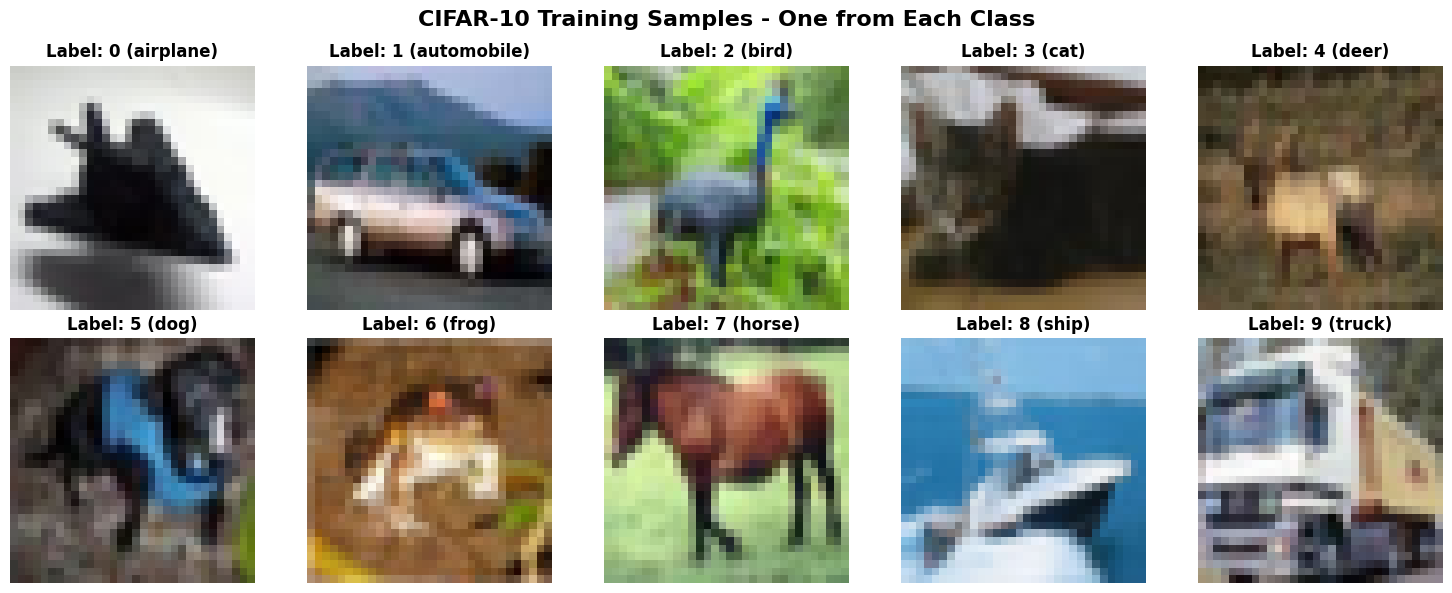

✅ Displayed one sample from each class with correct labels!


In [7]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('CIFAR-10 Training Samples - One from Each Class', fontsize=16, fontweight='bold')

for class_idx in range(10):
    row = class_idx // 5
    col = class_idx % 5
    ax = axes[row, col]
    
    # Find first sample of this class
    class_indices = np.where(y_train == class_idx)[0]
    sample_idx = class_indices[0]
    
    # Get image and label
    image = X_train[sample_idx]
    label = y_train[sample_idx]
    
    # Display image
    ax.imshow(image.astype(np.uint8))
    ax.set_title(f'Label: {label} ({class_names[label]})', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Verify label matches
    assert label == class_idx, f"Label mismatch: expected {class_idx}, got {label}"

plt.tight_layout()
plt.show()

print("✅ Displayed one sample from each class with correct labels!")


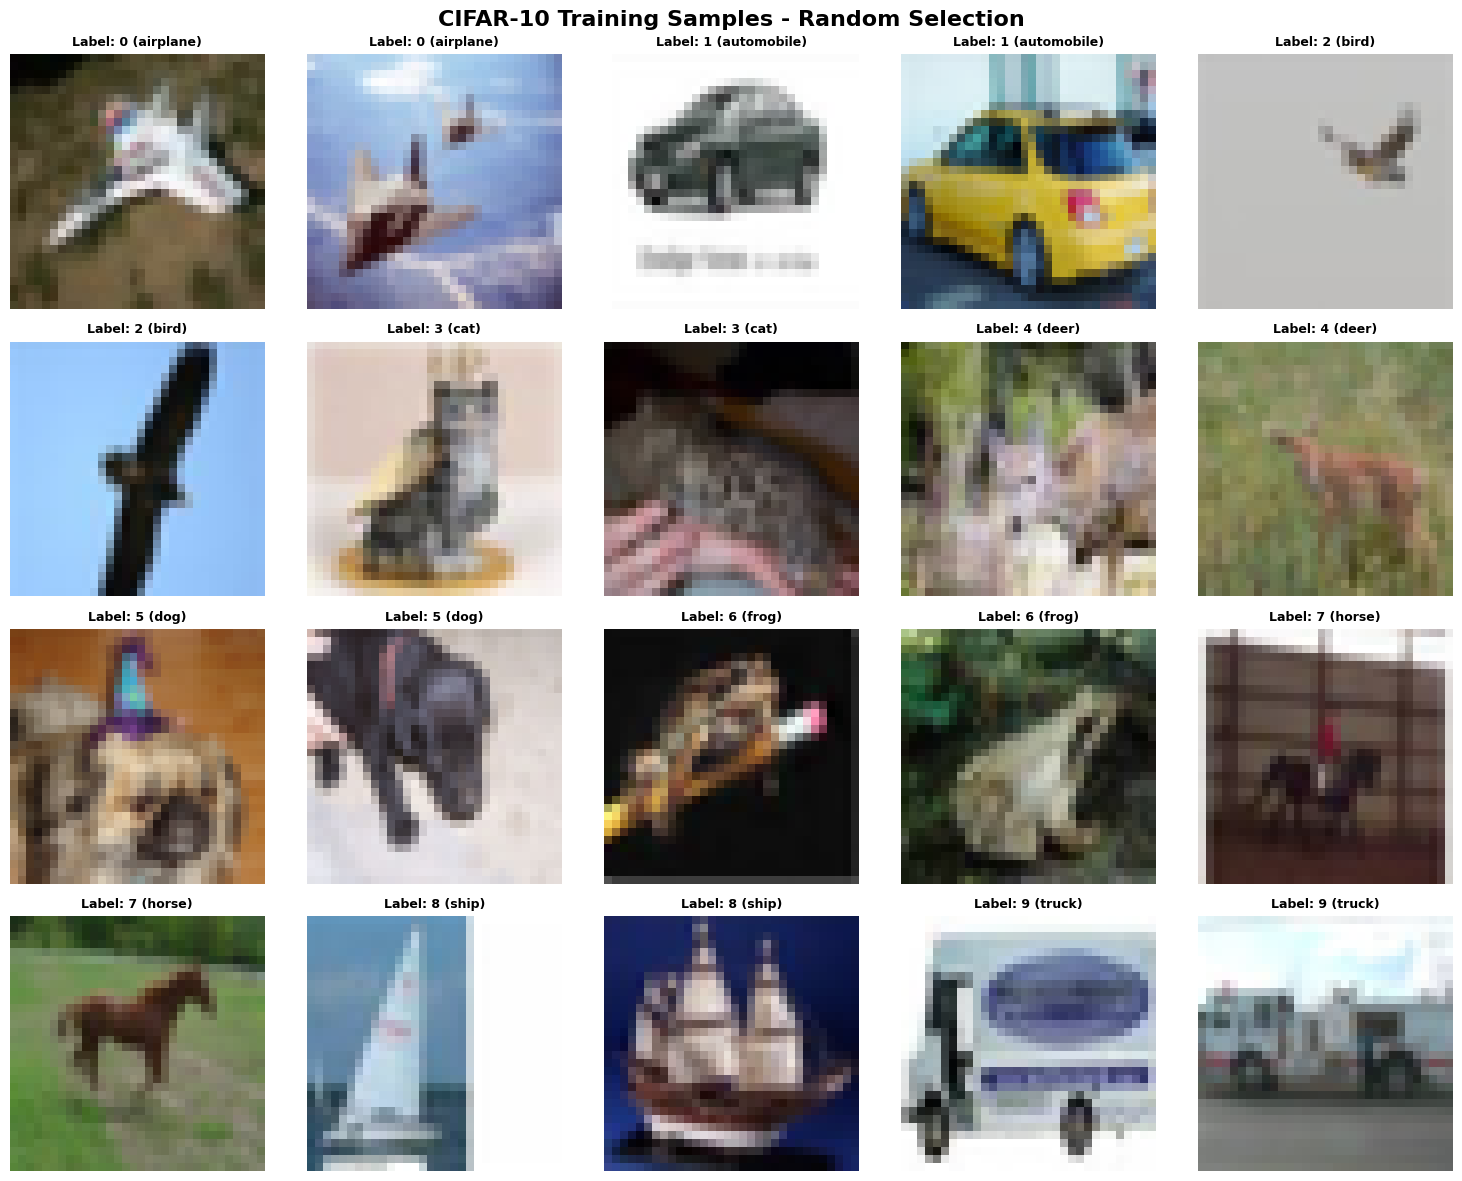

In [8]:
# Display more samples in a grid
num_samples = 20
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('CIFAR-10 Training Samples - Random Selection', fontsize=16, fontweight='bold')

# Select samples from different classes
samples_per_class = num_samples // 10
sample_indices = []

for class_idx in range(10):
    class_indices = np.where(y_train == class_idx)[0]
    selected = np.random.choice(class_indices, size=min(samples_per_class, len(class_indices)), replace=False)
    sample_indices.extend(selected)

# Fill remaining slots randomly
remaining = num_samples - len(sample_indices)
if remaining > 0:
    all_indices = np.arange(len(X_train))
    remaining_indices = np.random.choice(all_indices, size=remaining, replace=False)
    sample_indices.extend(remaining_indices)

sample_indices = sample_indices[:num_samples]

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_indices):
        img_idx = sample_indices[idx]
        image = X_train[img_idx]
        label = y_train[img_idx]
        
        # Display image
        ax.imshow(image.astype(np.uint8))
        ax.set_title(f'Label: {label} ({class_names[label]})', fontsize=9, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()


In [9]:
# Test preprocessing pipeline
print("Testing preprocessing pipeline...")
X_sample = X_train[:100]
y_sample = y_train[:100]

X_processed, y_processed = preprocess_data(
    X_sample, y_sample,
    num_classes=10,
    flatten=True,
    normalize=True
)

print(f"   Original shape: {X_sample.shape}")
print(f"   Processed shape: {X_processed.shape} (expected: (100, 3072))")
print(f"   Processed value range: {X_processed.min():.3f} - {X_processed.max():.3f} (expected: 0.0 - 1.0)")
print(f"   Labels shape: {y_processed.shape} (expected: (100, 10))")

assert X_processed.shape == (100, 3072), f"Expected flattened shape (100, 3072), got {X_processed.shape}"
assert y_processed.shape == (100, 10), f"Expected one-hot shape (100, 10), got {y_processed.shape}"
assert np.allclose(X_processed.min(), 0.0) and np.allclose(X_processed.max(), 1.0), "Normalization failed"

# Verify one-hot encoding
for i in range(10):
    label_idx = y_sample[i]
    one_hot = y_processed[i]
    assert one_hot[label_idx] == 1.0, f"One-hot encoding incorrect for sample {i}"
    assert np.sum(one_hot) == 1.0, f"One-hot encoding should sum to 1.0 for sample {i}"

print("✅ Preprocessing pipeline works correctly!")


Testing preprocessing pipeline...
   Original shape: (100, 32, 32, 3)
   Processed shape: (100, 3072) (expected: (100, 3072))
   Processed value range: 0.000 - 1.000 (expected: 0.0 - 1.0)
   Labels shape: (100, 10) (expected: (100, 10))
✅ Preprocessing pipeline works correctly!


In [10]:
# Verify label-image correspondence for each class
print("Verifying label-image correspondence for each class:")
print()

verification_passed = True
for class_idx in range(10):
    class_indices = np.where(y_train == class_idx)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        actual_label = y_train[sample_idx]
        if actual_label == class_idx:
            print(f"   ✅ Class {class_idx} ({class_names[class_idx]:15s}): Sample {sample_idx} has correct label {actual_label}")
        else:
            print(f"   ❌ Class {class_idx} ({class_names[class_idx]:15s}): Sample {sample_idx} has WRONG label {actual_label} (expected {class_idx})")
            verification_passed = False

if verification_passed:
    print("\n✅ All label-image correspondences are correct!")
else:
    print("\n❌ Some label-image correspondences are incorrect!")


Verifying label-image correspondence for each class:

   ✅ Class 0 (airplane       ): Sample 29 has correct label 0
   ✅ Class 1 (automobile     ): Sample 4 has correct label 1
   ✅ Class 2 (bird           ): Sample 6 has correct label 2
   ✅ Class 3 (cat            ): Sample 9 has correct label 3
   ✅ Class 4 (deer           ): Sample 3 has correct label 4
   ✅ Class 5 (dog            ): Sample 27 has correct label 5
   ✅ Class 6 (frog           ): Sample 0 has correct label 6
   ✅ Class 7 (horse          ): Sample 7 has correct label 7
   ✅ Class 8 (ship           ): Sample 8 has correct label 8
   ✅ Class 9 (truck          ): Sample 1 has correct label 9

✅ All label-image correspondences are correct!


## Summary

If all checks passed, your CIFAR-10 data is loaded correctly with correct labels!

**Key points verified:**
- ✅ Dataset shapes are correct (50000 training, 10000 test)
- ✅ Each class has exactly 5000 training samples
- ✅ Labels are in the correct range (0-9)
- ✅ Images are in the correct format (32x32x3 RGB, values 0-255)
- ✅ Label-image correspondence is correct
- ✅ Preprocessing pipeline works correctly (flattening and normalization)

**Your data is ready to be fed to your feedforward neural network!**

After preprocessing:
- Training images: 50,000 samples × 3,072 features (32×32×3 flattened)
- Test images: 10,000 samples × 3,072 features
- Labels: One-hot encoded (10 classes)
